In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio

HA_CAY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/CAY/ha_Q90_SMA_CAY.tif")
LA_CAY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/CAY/la_Q90_SMA_CAY.tif")
SOIL_CAY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/CAY/soil_Q90_SMA_CAY.tif")
VEG_CAY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/CAY/veg_Q90_SMA_CAY.tif")
mNDVI_CAY = Path("/mnt/intenso/masterarbeit/landsat/mNDVI_CAT/19840101-20251231_070-304_HL_TSA_LNDLG_NDV_CAY.tif")

HA_FBY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/FBY/ha_Q90_SMA_FBY.tif")
LA_FBY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/FBY/la_Q90_SMA_FBY.tif")
SOIL_FBY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/FBY/soil_Q90_SMA_FBY.tif")
VEG_FBY = Path("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/FBY/veg_Q90_SMA_FBY.tif")
mNDVI_FBY = Path("/mnt/intenso/masterarbeit/landsat/mNDVI_CAT/19840101-20251231_070-304_HL_TSA_LNDLG_NDV_FBY.tif")
rise_thresh = 2000
drop_thresh = 2000
amp_thresh  = 3000
max_window  = 5  # peak must collapse within <= x years

In [3]:
def read_CAY(path):
    with rio.open(path) as src:
        change = src.read(1, masked=True)
        changeyear = src.read(3, masked=True)
        totalsig = src.read(10, masked=True)

    return change, changeyear, totalsig

def read_FBY(path):
    with rio.open(path) as src:
        stack = src.read(masked=True)

    return stack

In [4]:
ts = read_FBY(SOIL_FBY)

In [5]:

T, H, W = ts.shape

start_year = 1985
years = np.arange(start_year, start_year + T)

ts_f = ts.astype("float32").filled(np.nan)    # (T, H, W)
d = np.diff(ts_f, axis=0)

rise = d >= rise_thresh
fall = d <= -drop_thresh

peak_found = np.zeros((H, W), dtype=bool)
peak_year  = np.full((H, W), np.nan, dtype="float32")

for t in range(T - 1):
    start = rise[t] # where a rise starts and we don't have a peak yet
    if not np.any(start):
        continue

    t1 = t + 1
    t2 = min(t + 1 + max_window, T - 1)  # search falls within window of diffs

    fall_win = fall[t1:t2]               # shape (Wlen, H, W)
    if fall_win.size == 0:
        continue

    has_fall = np.any(fall_win, axis=0) & start
    if not np.any(has_fall):
        continue

    first_fall_idx = np.argmax(fall_win, axis=0)  # offset within window
    # absolute diff index of the fall
    r = t1 + first_fall_idx

    # We consider the segment of samples ts_f[t .. r+1] (inclusive)
    Lmax = (t2 - t1) + 2                   # at most max_window+2 samples
    end_cap = min(t + Lmax, T)
    seg = ts_f[t:end_cap]                  # (L, H, W)
    L = seg.shape[0]

    steps = (r + 1) - t                    # per-pixel length from t to r+1
    l_idx = np.arange(L)[:, None, None]    # (L,1,1)
    include = l_idx <= steps[None, :, :]   # (L,H,W) True up to r+1, else False

    seg_masked = np.where(include, seg, np.nan)      # keep only the window we care about
    seg_valid  = np.isfinite(seg_masked)             # True where we have a real number

    # 1) Detect pixels with at least one valid value in the window
    has_valid_in_window = np.any(seg_valid, axis=0)  # (H, W)
    seg_filled = np.where(seg_valid, seg_masked, -np.inf)

    # 3) Safe max and "argmax" (works even if all were invalid; we’ll gate on has_valid_in_window)
    seg_max     = np.max(seg_filled, axis=0)         # (H, W); = -inf if no valid
    seg_argmax  = np.argmax(seg_filled, axis=0)      # (H, W); arbitrary if no valid, but we won't use it

    # 4) When computing amplitude, also ensure pre_val is finite
    pre_val   = ts_f[t]                               # (H, W)
    finite_pre = np.isfinite(pre_val)

    amplitude = seg_max - pre_val                     # (H, W); will be inf/-inf if seg_max is -inf

    # 5) Build the final good mask with all guards
    good = (
        (amplitude >= amp_thresh) &
        has_valid_in_window &
        finite_pre &
        has_fall
    )

    # 6) Write outputs only where good
    peak_found[good] = True
    peak_idx = t + seg_argmax
    peak_year_vals = years.take(peak_idx, mode='clip').astype("float32")
    peak_year[good] = peak_year_vals[good]  

In [5]:
with rio.open(SOIL_FBY) as src:
    profile = src.profile

out_profile = profile.copy()

out_profile.update(count=1, dtype="float32", nodata=np.nan)
with rio.open("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/soil_peakyear.tif", "w", **out_profile) as dst:
    dst.write(np.nan_to_num(peak_year, nan=np.float32(np.nan)), 1)

In [6]:
hac, hacy, hasig = read_CAY(HA_CAY)
lac, lacy, lasig = read_CAY(LA_CAY)
soilc, soilcy, soilsig = read_CAY(SOIL_CAY)
vegc, vegcy, vegsig = read_CAY(VEG_CAY)
mNDVIc, mNDVIcy, mNDVIsig = read_CAY(mNDVI_CAY)


veg_year = np.ma.masked_all(vegcy.shape, dtype=vegcy.dtype).astype("float32").filled(np.nan)

In [7]:
cond = (vegsig == -1)
veg_year[cond] = vegcy[cond]

diff = veg_year - peak_year # q90 vegetation fraction - soil fraction peak year


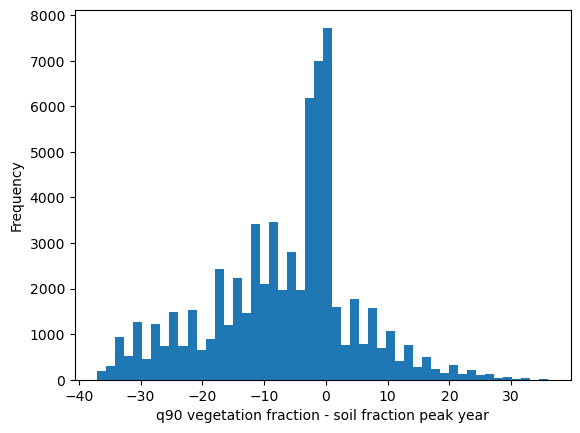

In [8]:

plt.hist(diff.ravel(), bins=50)  # ravel() flattens to 1D
plt.xlabel("q90 vegetation fraction - soil fraction peak year")
plt.ylabel("Frequency")
plt.show()

- Vegetation fraction drop first, then 1--3 years later soil peak

In [10]:
out_profile = profile.copy()

out_profile.update(count=1, dtype="float32", nodata=np.nan)
with rio.open("/mnt/intenso/masterarbeit/landsat/sma/noshadenorm/vegcatyear-soilpeakyear.tif", "w", **out_profile) as dst:
    dst.write(np.nan_to_num(diff, nan=np.float32(np.nan)), 1)

## Compare changeyears from CAT endmembers

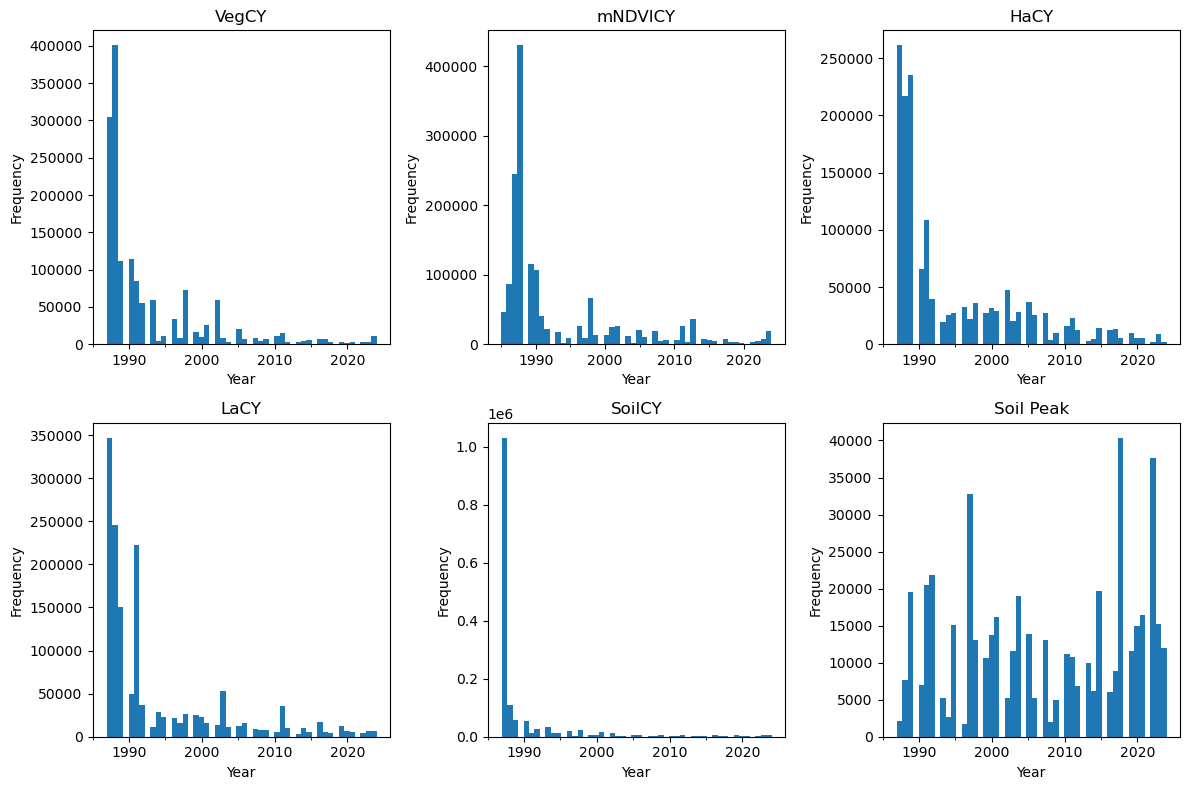

In [12]:
arrays = [vegcy, mNDVIcy, hacy, lacy, soilcy, peak_year]
titles = ["VegCY", "mNDVICY", "HaCY", "LaCY", "SoilCY", "Soil Peak"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2x2 grid
axes = axes.ravel()  # flatten to 1D for easy looping

for ax, arr, title in zip(axes, arrays, titles):
    # flatten and drop NaNs
    values = arr.compressed() if np.ma.isMaskedArray(arr) else arr.ravel()
    values = values[~np.isnan(values)]
    
    ax.hist(values, bins=50)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Frequency")
    ax.set_xticks([1985,1990,1995,2000,2005,2010,2015,2020],minor=True)

plt.tight_layout()
plt.show()

CAT Detects change in most pixels at the start of Timeseries

Maybe Water?

## CAT in Force

- Does it only capture negative change? 

## Retrieve building age

- Use max NDVI / Vegetation fraction CAT changeyear
- Using FBY Timeseries of SMA, Find Soil peaks
- If there is a soil peak, high- or low-albedo rise after mNDVI drop, use that year.
- Mask to building change predictions

### Problems

- Resolution difference between Landsat and Building mask (30m - 0.88m)
- Robust Endmember selection for Soil Low and High albedo
